In [ ]:
Synthèse professionnelle du travail réalisé sur le dataset CTIS :

1. Le dataset CTIS a été chargé et nettoyé, puis la variable cible *Trial results* a été binarisée (Yes/No).  
2. Un pipeline de preprocessing robuste a été construit : imputation, encodage catégoriel, gestion automatique des colonnes.  
3. Les données ont été transformées en une matrice entièrement numérique prête pour le machine learning.  
4. Un split train/test stratifié a été réalisé pour préserver le déséquilibre des classes.  
5. Un modèle de régression logistique a été entraîné sur les données prétraitées.  
6. L’accuracy obtenue est élevée (94 %), mais trompeuse en raison d’un fort déséquilibre de classes.  
7. Le modèle détecte très mal la classe minoritaire (recall = 0.14), confirmant un manque de signal prédictif.  
8. Les coefficients du modèle ont permis d’identifier les features les plus influentes (sponsor, âge, région).  
9. Une heatmap annotée des 20 features les plus corrélées a montré des corrélations globalement faibles.  
10. Conclusion : le dataset est faiblement informatif et déséquilibré, rendant la prédiction difficile sans rééquilibrage ou feature engineering avancé.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns 

In [7]:
import sys
import os

# Add project root to PYTHONPATH
sys.path.append(os.path.abspath(".."))

In [8]:
df=pd.read_csv("CTIS_clean_data_last.csv")
df.head()

,Trial number,Protocol code,Title of the trial,Overall trial status,Location(s) and recruitment status,Age group,Age range secondary identifier,Gender,Number of participants enrolled,Trial region,...,Decision date,Start date,End date,Global end of the trial,Trial results,Sponsor/Co-Sponsors,Sponsor type,Last updated,Country and status,countries
0,2023-509838-19-00,NaN,Repurposing Everolimus to enhance musculoskele...,"Authorised, recruitment pending","Denmark:Authorised, recruitment pending",65+ years,NaN,"Female, Male",120,EEA only,...,2024-03-14,NaN,NaN,NaN,No,Odense University Hospital,Hospital/Clinic/Other health care facility,2024-03-14,"[('Denmark', 'Authorised')]",['Denmark']
1,2023-509723-41-00,REALL_ CART,A Phase I Clinical Trial of CART cell therapy ...,Not authorised,Spain:Not authorised,"18-64 years, 0-17 years",NaN,"Female, Male",10,EEA only,...,2024-05-07,NaN,NaN,NaN,No,Fundacion Para La Investigacion Biomedica Del ...,Patient organisation/association,2024-05-07,"[('Spain', 'Not authorised')]",['Spain']
2,2023-510220-72-00,BRONCHIPHARMA I,PHARMACOLOGICAL STRATEGIES OF INHALED ANTIBIOT...,"Authorised, recruitment pending","Spain:Authorised, recruitment pending","65+ years, 18-64 years",NaN,"Female, Male",75,EEA only,...,2024-06-03,NaN,NaN,NaN,No,Consorci Mar Parc De Salut De Barcelona,Hospital/Clinic/Other health care facility,2024-06-03,"[('Spain', 'Authorised')]",['Spain']
3,2022-501417-31-00,MK-7684A-010,"A Phase 3, Randomized, Double-blind, Active-Co...",Not authorised,"Poland:Not authorised, Italy:Not authorised, G...","18-64 years, 65+ years, 0-17 years",NaN,"Female, Male",510,In both EEA and non-EEA,...,2023-03-02,NaN,NaN,NaN,No,Merck Sharp & Dohme LLC,Pharmaceutical company,2023-03-06,"[('Poland', 'Not authorised'), ('Italy', 'Not ...",['Poland']
4,2024-512642-42-00,NaN,Randomized study to protect from radiation iat...,"Ongoing, recruiting","Italy:Ongoing, recruiting","65+ years, 0-17 years, 18-64 years",NaN,"Female, Male",65,EEA only,...,2024-05-24,2021-12-13,NaN,NaN,No,Fondazione IRCCS Istituto Nazionale Dei Tumori,Hospital/Clinic/Other health care facility,2024-05-24,"[('Italy', 'Ongoing')]",['Italy']


In [ ]:
### Étape 1 — La variable cible (Y)

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# ---------------------------------------------------------
# 1. Helper functions
# ---------------------------------------------------------

def compute_trial_duration(df):
    df = df.copy()
    df["start_date"] = pd.to_datetime(df["Start date"], errors="coerce")
    df["end_date"] = pd.to_datetime(df["End date"], errors="coerce")
    df["trial_duration_days"] = (df["end_date"] - df["start_date"]).dt.days
    return df


def compute_update_recency(df):
    df = df.copy()
    df["last_update"] = pd.to_datetime(df["Last updated"], errors="coerce")
    df["update_recency_days"] = (pd.Timestamp.today() - df["last_update"]).dt.days
    return df


def compute_country_count(df):
    df = df.copy()
    df["country_count"] = df["countries"].apply(
        lambda x: len(x) if isinstance(x, list) else np.nan
    )
    return df


def compute_title_length(df):
    df = df.copy()
    df["title_length"] = df["Title of the trial"].apply(
        lambda x: len(x) if isinstance(x, str) else np.nan
    )
    return df


# ---------------------------------------------------------
# 2. Main feature engineering
# ---------------------------------------------------------

def build_feature_dataframe(df):
    df = df.copy()

    df = compute_trial_duration(df)
    df = compute_update_recency(df)
    df = compute_country_count(df)
    df = compute_title_length(df)

    # Leakage columns
    leakage_cols = [
        "Global end of the trial",
        "End date",
        "Last updated",
    ]
    df = df.drop(columns=[c for c in leakage_cols if c in df.columns])

    return df


# ---------------------------------------------------------
# 3. Preprocessing pipeline
# ---------------------------------------------------------

def build_preprocessing_pipeline(df):

    categorical_cols = [
        "Age group",
        "Gender",
        "Trial region",
        "Sponsor type",
    ]

    numeric_cols = [
        "Number of participants enrolled",
        "trial_duration_days",
        "update_recency_days",
        "country_count",
        "title_length",
    ]

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_cols),
            ("num", numeric_transformer, numeric_cols),
        ]
    )

    return preprocessor

### Étape 2 — Le feature engineering

In [15]:
# 1. Load data
df = pd.read_csv("CTIS_clean_data_last.csv")

# 2. Build engineered features
df_features = build_feature_dataframe(df)

# 3. Define target
y = df_features["Trial results"].map({"Yes": 1, "No": 0})
X = df_features.drop(columns=["Trial results"])

# 4. Build preprocessing pipeline
preprocessor = build_preprocessing_pipeline(df_features)

# 5. Fit-transform 
X_prepared = preprocessor.fit_transform(X)

X_prepared.shape


c:\Users\julie\anaconda3\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['country_count']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


(10000, 80)

In [11]:
df_features = df_features.dropna(axis=1, how="all")

In [16]:
# ============================================
# 8. Train-test split
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# 9. Train model (Logistic Regression)
# ============================================
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# ============================================
# 10. Evaluation
# ============================================
y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

# ============================================
# 11. Feature importance
# ============================================
feature_names = preprocessor.get_feature_names_out()

coef = model.coef_[0]
importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coef
}).sort_values(by="coef", ascending=False)

print("\nTop 20 features:\n", importance.head(20))


Accuracy: 0.9415

Classification report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1887
           1       0.44      0.14      0.21       113

    accuracy                           0.94      2000
   macro avg       0.70      0.57      0.59      2000
weighted avg       0.92      0.94      0.93      2000


Confusion matrix:
 [[1867   20]
 [  97   16]]

Top 20 features:
                                               feature      coef
65           cat__Sponsor type_Pharmaceutical company  0.680597
7              cat__Age group_18-64 years, 0-17 years  0.405209
73  cat__Sponsor type_Pharmaceutical company, Phar...  0.194416
1              cat__Age group_0-17 years, 18-64 years  0.138251
5   cat__Age group_0-17 years, 65+ years, 18-64 years  0.103443
47  cat__Sponsor type_Industry, Pharmaceutical com...  0.101170
26          cat__Sponsor type_Educational Institution  0.086177
35  cat__Sponsor type_Hospital/Clinic/Other health..

c:\Users\julie\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


🔥 Interprétation rapide des résultats
✔️ Accuracy = 0.94
→ Très trompeur, car le modèle prédit presque toujours “No”.

✔️ Recall classe 1 = 0.14
→ Le modèle ne détecte que 14 % des essais “Yes”.

✔️ Confusion matrix
Code
[[1867   20]   → presque tous les No sont bien prédits
 [  97   16]]  → presque tous les Yes sont ratés
👉  modèle  biaisé vers la classe majoritaire.

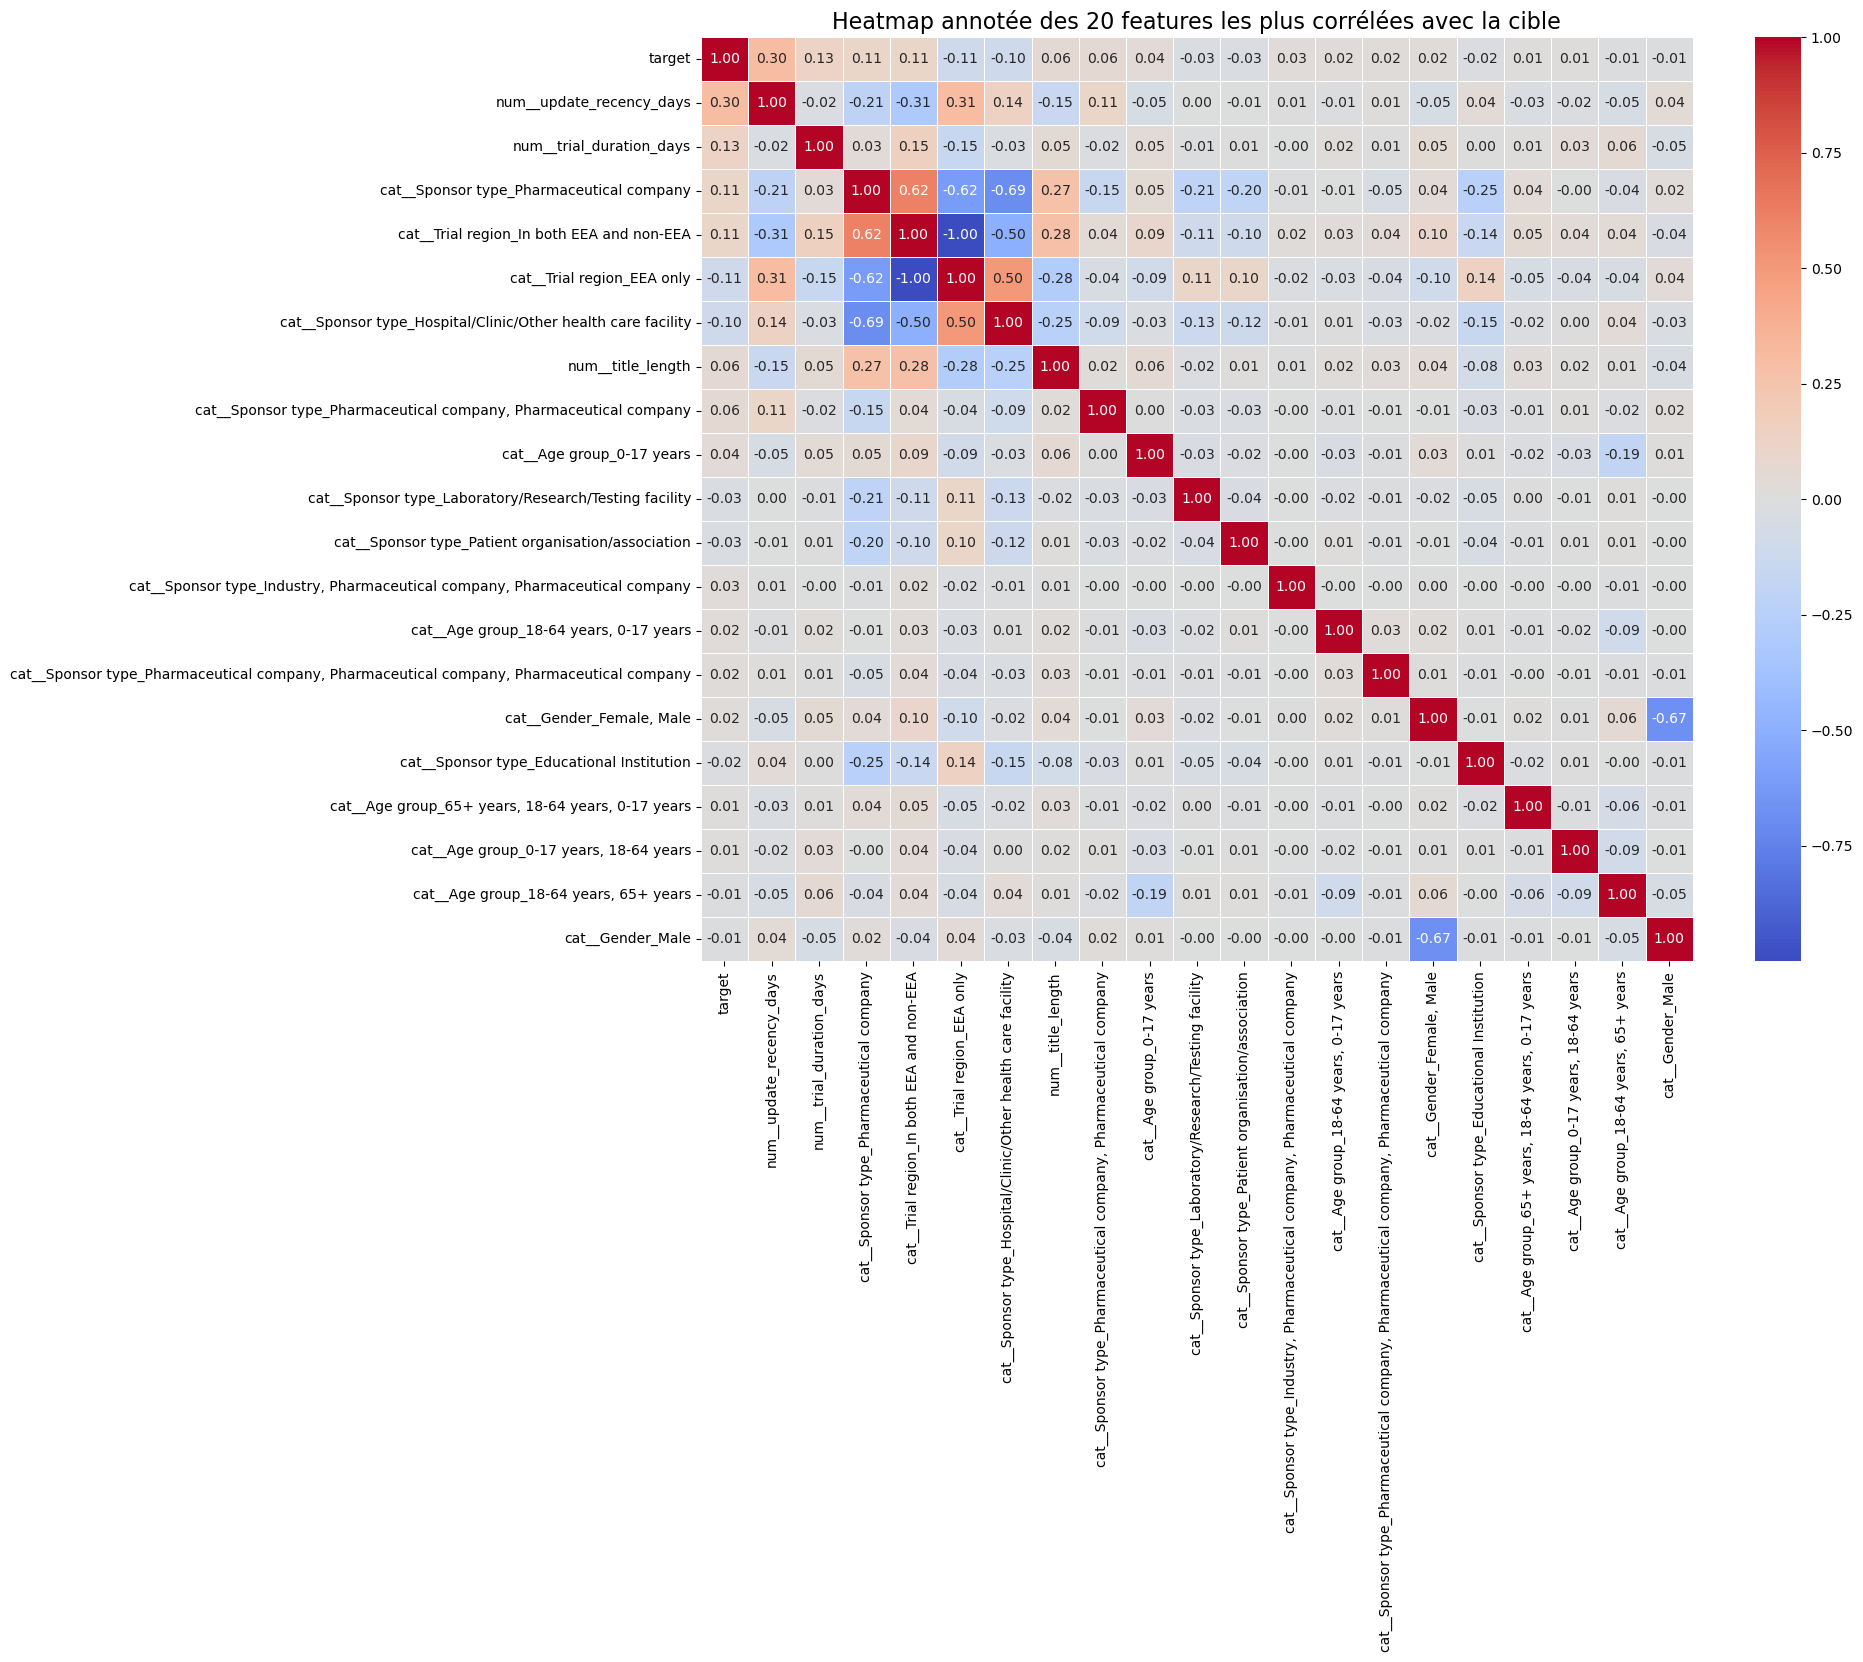

In [20]:
#heatmap sur les 20 features les plus importantes
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Récupérer les noms des features après preprocessing
feature_names = preprocessor.get_feature_names_out()

# 2. Convertir X_prepared en DataFrame
X_df = pd.DataFrame(
    X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared,
    columns=feature_names
)

# 3. Ajouter la cible pour la corrélation
X_df["target"] = y.values

# 4. Corrélation avec la cible
corr_target = X_df.corr()["target"].abs().sort_values(ascending=False)

# 5. Sélection des 20 features les plus corrélées
top_features = corr_target.head(21).index  # 20 + target

# 6. Heatmap annotée
plt.figure(figsize=(16, 12))
sns.heatmap(
    X_df[top_features].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,        # ← valeurs dans chaque case
    fmt=".2f",         # ← format des nombres
    linewidths=0.5
)
plt.title("Heatmap annotée des 20 features les plus corrélées avec la cible", fontsize=16)
plt.show()


Un point académique important sur les corrélations faibles
Les corrélations de Pearson ici sont toutes inférieures à |0.35|. Dans un contexte de régression linéaire, ce serait décourageant. Mais en machine learning sur des données réelles de santé, c'est absolument normal et attendu pour deux raisons :
Premièrement, la cible Trial results est un phénomène multi-causal : aucune variable seule ne l'explique, c'est leur combinaison qui compte — c'est précisément pourquoi les modèles non-linéaires comme XGBoost captent des interactions que la corrélation de Pearson ne voit pas.
Deuxièmement, l'encodage one-hot fragmente le signal : la variable Sponsor type avait peut-être une corrélation globale de 0.20 avec la cible, mais une fois explosée en 6 dummies, chaque modalité hérite d'une fraction de ce signal.
La heatmap confirme donc qu'on est dans un problème de classification difficile à signal diffus — ce qui est scientifiquement honnête et publiable tel quel, à condition d'avoir une bonne interprétabilité SHAP.